In [1]:
# Importamos las librerias
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings
import sweetviz as sv
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go
import matplotlib as mpl

warnings.filterwarnings("ignore")

os.listdir('../data')

# Parametros definidos para las gráficas
sns.set_theme(
    style="whitegrid",
    context="talk"
)

plt.rcParams["figure.figsize"] = (12, 6)

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.weight": "normal",
    "axes.labelweight": "normal",
    "axes.titleweight": "bold"
})

pio.templates.default = "plotly_white"
custom_template = go.layout.Template(
    layout={
        "font": {
            "family": "Arial",
            "size": 14
        },
        "title": {
            "x": 0.5,
            "xanchor": "center"
        },
        "plot_bgcolor": "white",
        "paper_bgcolor": "white",
        "hovermode": "closest",
        "legend": {
            "orientation": "h",
            "y": -0.2
        }
    }
)

pio.templates["portfolio"] = custom_template
pio.templates.default = "portfolio"

c:\Users\carme\OneDrive\Escritorio\Extra\vs_code\Fifa_Players_Performance_Analysis\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('../data/fifa_player.csv', index_col='player_id')
df.sample(5)

,player_name,age,nationality,club,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,injury_prone,transfer_risk_level
player_id,,,,,,,,,,,,,,,
2248,Player_2248,18,Spain,Juventus,CM,85,79,31,17,10,755,53.70,4,Yes,Medium
274,Player_274,20,Brazil,Manchester City,GK,92,89,20,36,22,2612,50.29,4,No,Low
590,Player_590,22,Portugal,Real Madrid,CDM,71,68,39,29,14,2193,155.07,5,No,Medium
1407,Player_1407,26,Argentina,FC Barcelona,CM,79,80,29,31,0,2996,110.22,5,No,Low
2227,Player_2227,21,Spain,PSG,ST,77,85,48,21,24,3670,36.35,4,No,Medium


In [3]:
df.describe()

,age,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left
count,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000
mean,27.952500,76.866786,81.563929,27.135714,19.261786,12.015000,2250.101429,90.565500,2.527857
std,6.750192,9.921113,9.755799,15.979627,11.567858,7.188459,1295.461829,52.078881,1.699445
min,17.000000,60.000000,65.000000,0.000000,0.000000,0.000000,0.000000,0.670000,0.000000
25%,22.000000,68.000000,73.000000,13.750000,9.000000,6.000000,1131.250000,45.355000,1.000000
50%,28.000000,77.000000,82.000000,27.000000,19.000000,12.000000,2251.000000,89.170000,3.000000
75%,34.000000,85.000000,90.000000,41.000000,30.000000,18.000000,3366.250000,136.682500,4.000000
max,39.000000,94.000000,98.000000,54.000000,39.000000,24.000000,4497.000000,179.960000,5.000000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2800 entries, 1 to 2800
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_name               2800 non-null   str    
 1   age                       2800 non-null   int64  
 2   nationality               2800 non-null   str    
 3   club                      2800 non-null   str    
 4   position                  2800 non-null   str    
 5   overall_rating            2800 non-null   int64  
 6   potential_rating          2800 non-null   int64  
 7   matches_played            2800 non-null   int64  
 8   goals                     2800 non-null   int64  
 9   assists                   2800 non-null   int64  
 10  minutes_played            2800 non-null   int64  
 11  market_value_million_eur  2800 non-null   float64
 12  contract_years_left       2800 non-null   int64  
 13  injury_prone              2800 non-null   str    
 14  transfer_risk_level

In [5]:
# Valores Nulos

df.isna().sum()

player_name                 0
age                         0
nationality                 0
club                        0
position                    0
overall_rating              0
potential_rating            0
matches_played              0
goals                       0
assists                     0
minutes_played              0
market_value_million_eur    0
contract_years_left         0
injury_prone                0
transfer_risk_level         0
dtype: int64

In [6]:
# Visualizar los clubs con mayores nº de jugadores en la FIFA

df['club'].value_counts().sort_values(ascending=False)

club
Juventus           439
Liverpool          412
Bayern Munich      396
Real Madrid        394
Manchester City    393
PSG                388
FC Barcelona       378
Name: count, dtype: int64

In [7]:
# Visulaizar la media de goles, asistencias, y minutos jugados relacionandolo con el riesgo de sufrir heridas
(
    df.groupby(by='player_name').agg({
    'goals': 'mean',
    'assists': 'mean',
    'minutes_played': 'mean',
    'injury_prone': 'sum'
    }).sort_values(by ='minutes_played', ascending=False)
)

,goals,assists,minutes_played,injury_prone
player_name,,,,
Player_1236,8.0,20.0,4497.0,No
Player_890,4.0,3.0,4494.0,No
Player_1084,14.0,14.0,4494.0,No
Player_641,27.0,6.0,4494.0,No
Player_468,23.0,18.0,4492.0,No
...,...,...,...,...
Player_1280,8.0,11.0,8.0,No
Player_1775,38.0,15.0,5.0,No
Player_2577,10.0,4.0,3.0,Yes


In [9]:
# Hacemos Agrupación en cuanto a nacionalidad, nombre del jugador y valor del mercado
nationality_df = (
    df.groupby("nationality")
      .agg(
          players=("player_name","count"),
          value=("market_value_million_eur","mean")
      )
      .sort_values("players", ascending=False)
)

fig = px.bar(
    nationality_df,
    x="players",
    y=nationality_df.index,
    orientation="h",
    color="value",
    color_continuous_scale="Viridis",
    title="Top Nacionalidades: número de jugadores y valor medio"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Número de jugadores",
    yaxis_title="Nacionalidad",
    title_x=0.5
)

fig.show()
fig.write_image("images/nacionalidades.png")

In [10]:
# Hacemos una agrupación por valor de la plantilla
club_values = (
    df.groupby("club")
      ["market_value_million_eur"]
      .sum()
      .sort_values(ascending=False)
)

club_values_df = club_values.reset_index()

fig = px.bar(
    club_values_df,
    x="market_value_million_eur",
    y="club",
    orientation="h",
    color="market_value_million_eur",
    color_continuous_scale="Blues",
    title="Top Clubes por valor total de plantilla"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Valor total (€ millones)",
    yaxis_title="Club",
    title_x=0.5
)

fig.show()

fig.write_image("images/cluberporplantilla.png")

In [11]:
report = sv.analyze(df)

report.show_html('report.html')

Feature: age                                 |█▎        | [ 12%]   00:00 -> (00:00 left)findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
Feature: nationality                         |█▉        | [ 19%]   00:00 -> (00:03 left)findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal,

Report report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


findfont: Failed to find font weight bold, now using 500.


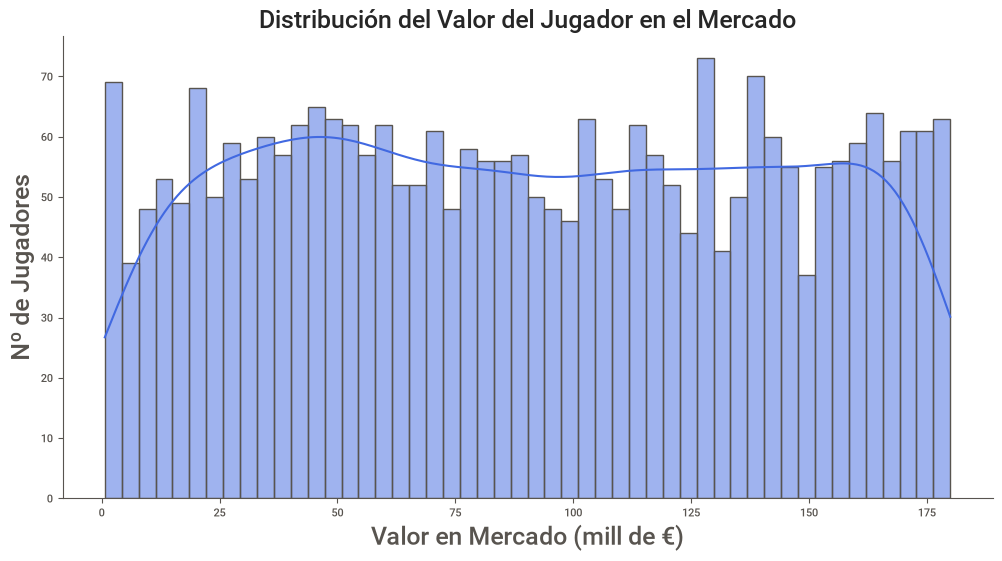

In [12]:
# Distibución del Valor en El Mercado.
plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x="market_value_million_eur",
    bins=50,
    kde=True,
    color = 'royalblue'
)

plt.title(
    "Distribución del Valor del Jugador en el Mercado",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Valor en Mercado (mill de €)")
plt.ylabel("Nº de Jugadores")

sns.despine()

plt.show()

In [13]:
# Gráfico para ver la calidad del jugados y su precio en el Mercado
fig = px.scatter(
    df,
    x="overall_rating",
    y="market_value_million_eur",
    color="position",
    size="goals",
    hover_data={
        "age": True,
        "club": True,
        "position": True,
        "overall_rating": True,
        "goals": True,
        "assists": True,
        "market_value_million_eur": ":.1f"
    },
    opacity=0.7,
    title="Calidad del Jugador vs Valor del Mercado"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Rating General",
    yaxis_title="Valor Del Mercado (€ Millones)",
    legend_title="Posición",
    height=700
)

fig.show()

fig.write_image("images/calidadyvalor.png")

In [14]:
# Top 15 jugadores más valiosos
top15 = (
    df.nlargest(15, "market_value_million_eur")
      .sort_values("market_value_million_eur")
)

fig = px.bar(
    top15,
    x="market_value_million_eur",
    y="player_name",
    orientation="h",
    color="goals",
    color_continuous_scale="Viridis",
    text="market_value_million_eur",
    hover_data={
        "age": True,
        "club": True,
        "position": True,
        "overall_rating": True,
        "goals": True,
        "market_value_million_eur": ":.1f"
    }
)

fig.update_traces(
    texttemplate="€%{x:.1f}M",
    textposition="outside"
)

fig.update_layout(
    title={
        "text": "Top 15 Jugadores Más Valiosos",
        "x": 0.5,
        "xanchor": "center"
    },
    xaxis_title="Valor de Mercado (€ Millones)",
    yaxis_title="",
    template="plotly_white",
    height=700,
    width=1200,
    coloraxis_colorbar=dict(
        title="Goles"
    )
)

fig.show()

fig.write_image("images/jugadoresvaliosos.png")

In [15]:
# Valor Del Mercado según la Posición
fig = px.violin(
    df,
    x="position",
    y="market_value_million_eur",
    box=True,
    points="all",
    title="Valor Del Mercado según la Posición",
    color="position"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="",
    yaxis_title="Valor En El Mercado (€ Millones)",
    height=650,
    showlegend=False
)

fig.show()

fig.write_image("images/valorposicion.png")

In [16]:
# Relación Entre El Riesgo de Transferencia y Su Valor en El Mercado

risk_stats = (
    df.groupby("transfer_risk_level")["market_value_million_eur"]
    .mean()
    .reset_index()
)

fig = px.bar(
    risk_stats,
    x="transfer_risk_level",
    y="market_value_million_eur",
    color="market_value_million_eur",
    color_continuous_scale="Viridis",
    title="Valor Medio del Mercado por Riesgo de Transferencia"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Riesgo de Transferencia",
    yaxis_title="Valor En El Mercado (€ Millones)",
    height=600
)

fig.show()

fig.write_image("images/valortransferencia.png")

In [17]:
# Panorama Del Valor del Mercado del Jugador

fig = px.scatter(
    df,
    x="age",
    y="market_value_million_eur",
    color="position",
    size="overall_rating",
    hover_data={
        "club": True,
        "position": True,
        "overall_rating": True,
        "goals": True,
        "assists": True
    },
    opacity=0.7,
    title="Panorama Del Valor del Mercado del Jugador"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Edad",
    yaxis_title="Valor En El Mercado (€ Millones)",
    height=750
)

fig.show()
fig.write_image("images/panorama.png")

In [18]:
# Heatmap: Matriz de Correlaciones

numeric = df.select_dtypes(include="number")
corr = numeric.corr()

fig = go.Figure(
    data=go.Heatmap(
        z=corr.values,
        x=corr.columns,
        y=corr.columns,
        colorscale="RdBu",
        zmid=0,
        text=np.round(corr.values, 2),
        texttemplate="%{text}"
    )
)

fig.update_layout(
    title="Heatmap",
    title_x=0.5,
    template="plotly_white",
    height=700,
    width=800
)

fig.show()

fig.write_image("images/heatmap.png")